# A4: Flood Experiment Results

Analyses the 3 flood scenarios from `model_run.py`:
- **Scenario 0**: Baseline — no flood
- **Scenario 1**: Small flood at tick 1440 (intensity ×0.5)
- **Scenario 2**: High intensity flood at tick 1440 (intensity ×1.0, full spatial risk)

**Run order**: `model_run.py` → this notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_EXP = '../data/experiment/'
DATA_PROC = '../data/data_processed/'
FLOOD_TICK = 1440
SCENARIOS = {0: 'Baseline (no flood)', 1: 'Small flood', 2: 'High intensity flood'}
COLOURS   = {0: '#888888', 1: '#F5A623', 2: '#D0021B'}

# Load all CSVs
dfs_ts    = {s: pd.read_csv(DATA_EXP + f'scenario{s}_timeseries.csv') for s in SCENARIOS}
dfs_infra = {s: pd.read_csv(DATA_EXP + f'scenario{s}_infra.csv')      for s in SCENARIOS}
dfs_sum   = {s: pd.read_csv(DATA_EXP + f'scenario{s}.csv')            for s in SCENARIOS}

print('Loaded. Timeseries rows:', {s: len(v) for s, v in dfs_ts.items()})

Loaded. Timeseries rows: {0: 492245, 1: 472930, 2: 454332}


## Plot 1: Travel time time-series
Rolling mean travel time per 200-tick window, averaged over 5 seeds. The vertical dashed line marks the flood event.

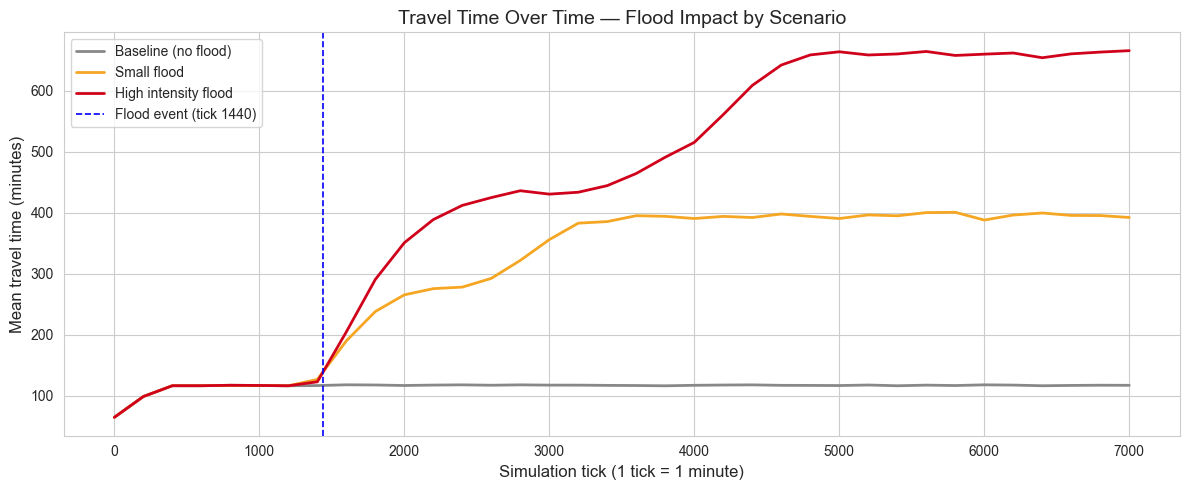

In [2]:
WINDOW = 200  # ticks per rolling bin

fig, ax = plt.subplots(figsize=(12, 5))

for s, label in SCENARIOS.items():
    df = dfs_ts[s].copy()
    # Bin ticks into windows and compute mean per bin, then average over seeds
    df['bin'] = (df['tick'] // WINDOW) * WINDOW
    mean_per_seed = df.groupby(['Seed', 'bin'])['travel_time'].mean().reset_index()
    mean_all = mean_per_seed.groupby('bin')['travel_time'].mean()
    ax.plot(mean_all.index, mean_all.values, label=label, color=COLOURS[s], linewidth=2)

ax.axvline(FLOOD_TICK, color='blue', linestyle='--', linewidth=1.2, label='Flood event (tick 1440)')
ax.set_xlabel('Simulation tick (1 tick = 1 minute)', fontsize=12)
ax.set_ylabel('Mean travel time (minutes)', fontsize=12)
ax.set_title('Travel Time Over Time — Flood Impact by Scenario', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC + 'flood_timeseries.png', dpi=150)
plt.show()

## Plot 2: Pre vs post-flood travel time (box plot)
Statistical comparison of travel times before and after the flood, per scenario.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
Y_CAP = 800

for ax, (s, label) in zip(axes, SCENARIOS.items()):
    df = dfs_ts[s]
    phases = df['phase'].unique().tolist()
    data   = [df[df['phase'] == p]['travel_time'].values for p in phases]
    bp = ax.boxplot(data, patch_artist=True, labels=phases,
                    medianprops={'color': 'black', 'linewidth': 2})
    phase_colours = {'pre_flood': '#4CAF50', 'post_flood': '#F44336', 'no_flood': '#9E9E9E'}
    for patch, phase in zip(bp['boxes'], phases):
        patch.set_facecolor(phase_colours.get(phase, '#BBBBBB'))
    ax.set_title(f'S{s}: {label}', fontsize=11)
    ax.set_xlabel('Phase')
    ax.set_ylim(0, Y_CAP)
    ax.tick_params(axis='x', labelrotation=15)

axes[0].set_ylabel('Travel time (minutes)', fontsize=12)
fig.suptitle('Pre vs Post-Flood Travel Times by Scenario\n(y-axis capped at 800 min; extreme outliers exist above)', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_PROC + 'flood_boxplot.png', dpi=150)
plt.show()

## Plot 3: Bridges broken by road × condition (Scenario 2)
Shows spatial differentiation: N1 (Jamuna floodplain, risk=1.0) vs N2 (northeast hills, risk=0.4).

/var/folders/04/yj5x8lbx49sc1jbf3gyzwr3h0000gn/T/ipykernel_42978/3024735471.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bridges['broke_during_flood'] = bridges['broke_during_flood'].fillna(False).astype(bool)


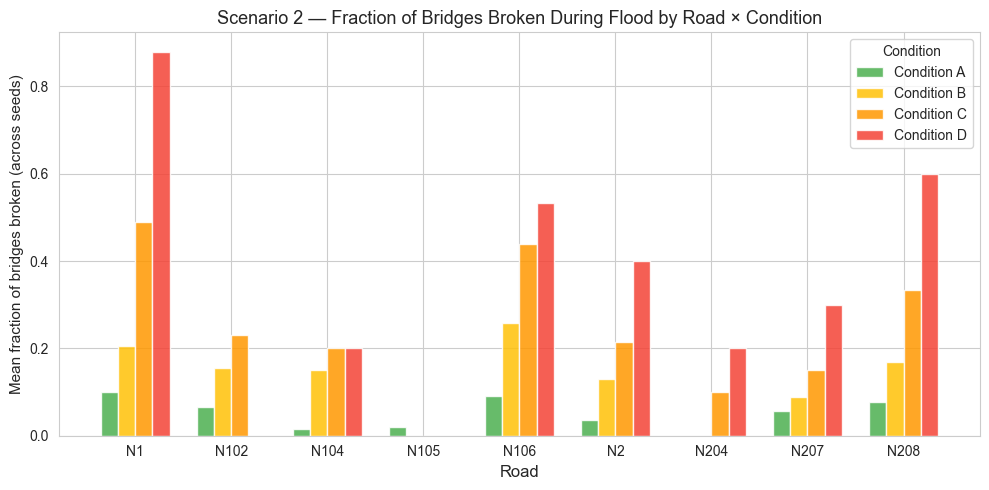

In [4]:
df_infra2 = dfs_infra[2].copy()
# Only bridges; aggregate over seeds (count how many times broke_during_flood==True)
bridges = df_infra2[df_infra2['agent_type'] == 'Bridge'].copy()
bridges['broke_during_flood'] = bridges['broke_during_flood'].fillna(False).astype(bool)

# Mean broke rate per road × condition across seeds
broke = bridges.groupby(['road', 'condition'])['broke_during_flood'].mean().unstack(fill_value=0)

cond_colours = {'A': '#4CAF50', 'B': '#FFC107', 'C': '#FF9800', 'D': '#F44336'}
conditions = [c for c in ['A', 'B', 'C', 'D'] if c in broke.columns]

x = np.arange(len(broke.index))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, cond in enumerate(conditions):
    ax.bar(x + i * width, broke[cond], width, label=f'Condition {cond}',
           color=cond_colours[cond], alpha=0.85)

ax.set_xticks(x + width * (len(conditions) - 1) / 2)
ax.set_xticklabels(broke.index)
ax.set_xlabel('Road', fontsize=12)
ax.set_ylabel('Mean fraction of bridges broken (across seeds)', fontsize=11)
ax.set_title('Scenario 2 — Fraction of Bridges Broken During Flood by Road × Condition', fontsize=13)
ax.legend(title='Condition')
plt.tight_layout()
plt.savefig(DATA_PROC + 'flood_broken_by_road.png', dpi=150)
plt.show()

## Plot 4: Summary table — avg travel time pre vs post flood

In [5]:
rows = []
for s, label in SCENARIOS.items():
    df = dfs_ts[s]
    pre  = df[df['phase'] == 'pre_flood']['travel_time'].mean()
    post = df[df['phase'] == 'post_flood']['travel_time'].mean()
    base = df[df['phase'] == 'no_flood']['travel_time'].mean()
    if pd.isna(pre):   pre  = base
    if pd.isna(post):  post = base
    pct = ((post - pre) / pre * 100) if pre and pre > 0 else float('nan')
    rows.append({
        'Scenario': f'S{s}: {label}',
        'Avg travel time pre-flood (min)':  round(pre,  1),
        'Avg travel time post-flood (min)': round(post, 1),
        'Increase (%)': round(pct, 1) if not pd.isna(pct) else '-',
    })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))
df_summary

                Scenario  Avg travel time pre-flood (min)  Avg travel time post-flood (min)  Increase (%)
 S0: Baseline (no flood)                            116.3                             116.3           0.0
         S1: Small flood                            110.7                             361.7         226.7
S2: High intensity flood                            110.7                             548.7         395.6


,Scenario,Avg travel time pre-flood (min),Avg travel time post-flood (min),Increase (%)
0,S0: Baseline (no flood),116.3,116.3,0.0
1,S1: Small flood,110.7,361.7,226.7
2,S2: High intensity flood,110.7,548.7,395.6


## Plot 5: Geographic map — broken bridges
Bubble size = total trucks passed (empirical criticality from S0). Red = broke during high-intensity flood (S2).

In [ ]:
# Load bridge coordinates from network CSV (no longer needs bridge_analysis.csv)
df_network = pd.read_csv('../data/data_processed/A3_network_roads.csv')
df_network['model_type'] = df_network['model_type'].str.strip().str.lower()
bridge_coords = df_network[df_network['model_type'] == 'bridge'][['id', 'lat', 'lon']].rename(columns={'id': 'agent_id'})

# Empirical criticality: avg trucks passed per bridge in scenario 0
crit_s0 = (dfs_infra[0][dfs_infra[0]['agent_type'] == 'Bridge']
           .groupby('agent_id')['total_vehicles_passed'].mean()
           .reset_index().rename(columns={'total_vehicles_passed': 'trucks_s0'}))

# Vulnerability: broke rate per bridge in scenario 2
broke_s2 = dfs_infra[2][dfs_infra[2]['agent_type'] == 'Bridge'].copy()
broke_s2['broke_during_flood'] = broke_s2['broke_during_flood'].fillna(False).astype(bool)
broke_rate = (broke_s2.groupby('agent_id')['broke_during_flood'].mean()
              .reset_index().rename(columns={'broke_during_flood': 'broke_rate'}))
broke_majority = broke_rate.copy()
broke_majority['broke'] = broke_majority['broke_rate'] >= 0.5

df_map = bridge_coords.merge(crit_s0, on='agent_id', how='left').merge(broke_majority, on='agent_id', how='left')
df_map['trucks_s0'] = df_map['trucks_s0'].fillna(0)
df_map['broke'] = df_map['broke'].fillna(False)

trucks = df_map['trucks_s0'].values
sizes = 10 + 300 * (trucks / (trucks.max() + 1e-9))

fig, ax = plt.subplots(figsize=(8, 12))
ax.scatter(df_map['lon'], df_map['lat'], s=sizes, c='#BBBBBB',
           alpha=0.6, edgecolors='#888888', linewidths=0.3, label='Bridge (intact)')
mask_broke = df_map['broke']
ax.scatter(df_map[mask_broke]['lon'], df_map[mask_broke]['lat'],
           s=sizes[mask_broke], c='#D0021B',
           alpha=0.85, edgecolors='darkred', linewidths=0.5, label='Broke during flood (S2)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Scenario 2: Broken Bridges\n(size = trucks passed = empirical criticality)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC + 'flood_geo_broken.png', dpi=150)
plt.show()
print(f'Total bridges: {len(df_map)} | Broke in ≥50% of seeds: {mask_broke.sum()}')

## Plot 6: Top 15 bridges by truck count — Baseline Scenario

In [ ]:
bridges_s0 = dfs_infra[0][dfs_infra[0]['agent_type'] == 'Bridge'].copy()
bridge_flow = bridges_s0.groupby(['agent_id', 'name', 'road', 'condition'])['total_vehicles_passed'].mean().reset_index()
bridge_flow = bridge_flow.sort_values('total_vehicles_passed', ascending=False)

top15 = bridge_flow.head(15)
road_colours = {
    'N1': '#1f77b4', 'N2': '#ff7f0e', 'N102': '#2ca02c',
    'N104': '#9467bd', 'N105': '#8c564b', 'N106': '#aec7e8',
    'N204': '#ffbb78', 'N207': '#f5c000', 'N208': '#d62728',
}
bar_colours = [road_colours.get(r, '#888888') for r in top15['road']]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top15['name'], top15['total_vehicles_passed'], color=bar_colours, alpha=0.85)
ax.set_xlabel('Total trucks passed (average over 5 seeds, 120h simulation)', fontsize=11)
ax.set_title('Top 15 Bridges by Number of Trucks — Baseline Scenario', fontsize=13)
ax.invert_yaxis()
handles = [mpatches.Patch(color=c, label=r) for r, c in road_colours.items()]
ax.legend(handles=handles, title='Road', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(DATA_PROC + 'bridge_truck_flow_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top bridge: {top15.iloc[0]["name"]} ({top15.iloc[0]["road"]}) — {top15.iloc[0]["total_vehicles_passed"]:,.0f} trucks')

In [ ]:
# ── Plot 6b: Geographic map — bubble size = trucks, colour = condition ───────
df_geo = bridge_coords.merge(bridge_flow[['agent_id', 'total_vehicles_passed', 'condition']], on='agent_id', how='left')
df_geo['total_vehicles_passed'] = df_geo['total_vehicles_passed'].fillna(0)
trucks = df_geo['total_vehicles_passed'].values
sizes = 10 + 300 * (trucks / (trucks.max() + 1e-9))
cond_cmap = {'A': '#4CAF50', 'B': '#FFC107', 'C': '#FF9800', 'D': '#F44336'}
point_colours = [cond_cmap.get(str(c).strip().upper(), '#BBBBBB') for c in df_geo['condition']]

fig, ax = plt.subplots(figsize=(8, 12))
ax.scatter(df_geo['lon'], df_geo['lat'], s=sizes, c=point_colours, alpha=0.75, edgecolors='grey', linewidths=0.3)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Simulated Truck Flow per Bridge\n(bubble size = total trucks, colour = condition)', fontsize=13)
cond_handles = [mpatches.Patch(color=c, label=f'Condition {k}') for k, c in cond_cmap.items()]
ax.legend(handles=cond_handles, title='Bridge condition', loc='lower right')
plt.tight_layout()
plt.savefig(DATA_PROC + 'bridge_truck_flow_geo.png', dpi=150)
plt.show()

## Table: Most critical and vulnerable bridges
Combines empirical criticality (trucks passed in S0) with empirical vulnerability (broke rate in S2). Bridges are ranked by trucks passed. Condition and broke rate together show which bridges are both heavily used and at high flood risk.

In [ ]:
# Empirical criticality: avg trucks passed per bridge in S0
crit_df = (dfs_infra[0][dfs_infra[0]['agent_type'] == 'Bridge']
           .groupby(['agent_id', 'name', 'road', 'condition'])['total_vehicles_passed']
           .mean().reset_index())

# Empirical vulnerability: broke rate per bridge in S2
vuln_df = (dfs_infra[2][dfs_infra[2]['agent_type'] == 'Bridge']
           .assign(broke=lambda d: d['broke_during_flood'].fillna(False).astype(bool))
           .groupby('agent_id')['broke'].mean().reset_index()
           .rename(columns={'broke': 'broke_rate'}))

table_df = crit_df.merge(vuln_df, on='agent_id', how='left')
table_df['broke_rate'] = (table_df['broke_rate'].fillna(0) * 100).round(0).astype(int)
table_df = table_df.sort_values('total_vehicles_passed', ascending=False).head(20)

table_df = table_df.rename(columns={
    'name': 'Bridge',
    'road': 'Road',
    'condition': 'Condition',
    'total_vehicles_passed': 'Trucks passed (S0)',
    'broke_rate': 'Broke in flood S2 (%)',
})

print('Top 20 bridges by truck count — with flood vulnerability')
print(table_df[['Bridge', 'Road', 'Condition', 'Trucks passed (S0)', 'Broke in flood S2 (%)']].to_string(index=False))
table_df[['Bridge', 'Road', 'Condition', 'Trucks passed (S0)', 'Broke in flood S2 (%)')]